## Setup

In [1]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (
    shapiro, levene, ttest_ind,
    pearsonr, spearmanr, f_oneway
)
import sys
import os
sys.path.append("../src")
from config import DB_PATH, FIGURES_DIR

con = duckdb.connect(DB_PATH)
os.makedirs(FIGURES_DIR, exist_ok=True)

df = con.execute("SELECT * FROM features_with_risk").df()
print(f"Loaded: {df.shape}")
print(f"Districts: {df['region'].nunique()}")
print(f"Years: {df['year'].min()} – {df['year'].max()}")

Loaded: (407, 67)
Districts: 22
Years: 2000 – 2024


##  Normality Check (Shapiro-Wilk):

TEST 1 — Normality of Yield Distribution
Shapiro-Wilk Test
H0: yield is normally distributed
H1: yield is NOT normally distributed

  W-statistic: 0.9465
  p-value:     0.0000
  Result: REJECT H0 → yield is NOT normally distributed
  → We should use non-parametric tests where appropriate


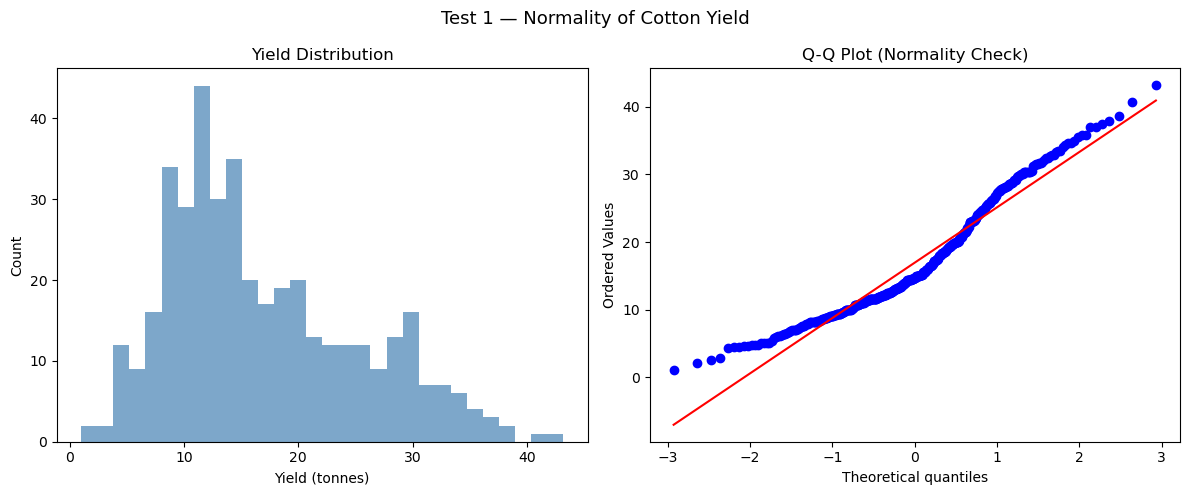

Saved: stat_01_normality.png


In [2]:


print("=" * 55)
print("TEST 1 — Normality of Yield Distribution")
print("Shapiro-Wilk Test")
print("H0: yield is normally distributed")
print("H1: yield is NOT normally distributed")
print("=" * 55)

stat, p = shapiro(df["yield_tonnes"].dropna())
print(f"\n  W-statistic: {stat:.4f}")
print(f"  p-value:     {p:.4f}")

if p > 0.05:
    print("  Result: FAIL TO REJECT H0 → yield is approximately normal ✓")
else:
    print("  Result: REJECT H0 → yield is NOT normally distributed")
    print("  → We should use non-parametric tests where appropriate")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["yield_tonnes"], bins=30, color="steelblue", alpha=0.7)
axes[0].set_title("Yield Distribution")
axes[0].set_xlabel("Yield (tonnes)")
axes[0].set_ylabel("Count")

stats.probplot(df["yield_tonnes"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot (Normality Check)")

plt.suptitle("Test 1 — Normality of Cotton Yield", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "stat_01_normality.png"), dpi=150)
plt.show()
print("Saved: stat_01_normality.png")

## Hypothesis Test: Risky vs Safe Years (t-test):

TEST 2 — Yield Difference: Safe vs Risky Years
Independent Samples t-test
H0: mean yield is the SAME in safe and risky years
H1: risky years have LOWER mean yield

  Safe  years: n=264,  mean=20.65t,  std=7.85
  Risky years: n=143, mean=10.10t, std=3.72

  Levene's test (equal variance): p=0.0000

  t-statistic: 18.3725
  p-value (one-tailed): 0.0000
  Result: REJECT H0 ✓ → risky years have significantly lower yield

  Effect size (Cohen's d): 1.719
  Interpretation: large effect


C:\Users\User\AppData\Local\Temp\ipykernel_19956\2827875104.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([safe, risky], labels=["Safe (label=0)", "Risky (label=1)"],


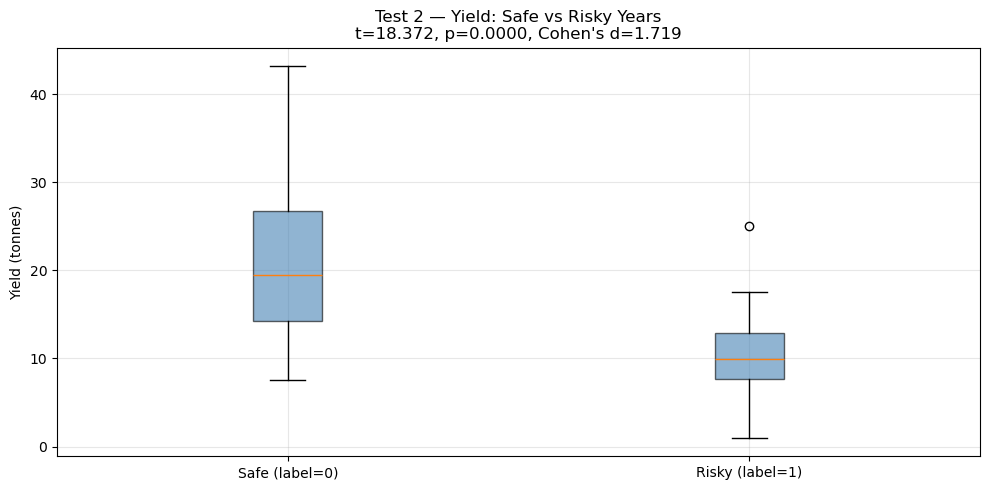

Saved: stat_02_safe_vs_risky.png


In [3]:
print("=" * 55)
print("TEST 2 — Yield Difference: Safe vs Risky Years")
print("Independent Samples t-test")
print("H0: mean yield is the SAME in safe and risky years")
print("H1: risky years have LOWER mean yield")
print("=" * 55)

safe  = df[df["overall_risk_label"] == 0]["yield_tonnes"]
risky = df[df["overall_risk_label"] == 1]["yield_tonnes"]

print(f"\n  Safe  years: n={len(safe)},  mean={safe.mean():.2f}t,  std={safe.std():.2f}")
print(f"  Risky years: n={len(risky)}, mean={risky.mean():.2f}t, std={risky.std():.2f}")

# Levene's test first (check equal variance assumption)
lev_stat, lev_p = levene(safe, risky)
print(f"\n  Levene's test (equal variance): p={lev_p:.4f}")
equal_var = lev_p > 0.05

# t-test
t_stat, p_two = ttest_ind(safe, risky, equal_var=equal_var)
p_one = p_two / 2  # one-tailed (risky < safe)

print(f"\n  t-statistic: {t_stat:.4f}")
print(f"  p-value (one-tailed): {p_one:.4f}")

if p_one < 0.05:
    print("  Result: REJECT H0 ✓ → risky years have significantly lower yield")
else:
    print("  Result: FAIL TO REJECT H0 → no significant difference found")

# Cohen's d (effect size)
pooled_std = np.sqrt((safe.std()**2 + risky.std()**2) / 2)
cohens_d   = (safe.mean() - risky.mean()) / pooled_std
print(f"\n  Effect size (Cohen's d): {cohens_d:.3f}")
if abs(cohens_d) < 0.2:
    effect = "negligible"
elif abs(cohens_d) < 0.5:
    effect = "small"
elif abs(cohens_d) < 0.8:
    effect = "medium"
else:
    effect = "large"
print(f"  Interpretation: {effect} effect")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([safe, risky], labels=["Safe (label=0)", "Risky (label=1)"],
           patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6))
ax.set_title(f"Test 2 — Yield: Safe vs Risky Years\n"
             f"t={t_stat:.3f}, p={p_one:.4f}, Cohen's d={cohens_d:.3f}")
ax.set_ylabel("Yield (tonnes)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "stat_02_safe_vs_risky.png"), dpi=150)
plt.show()
print("Saved: stat_02_safe_vs_risky.png")

## Correlation Tests (GDD, Rain vs Yield):

TEST 3 — Feature Correlations with Yield
Pearson + Spearman Correlation Tests
H0: feature has NO correlation with yield (r=0)
H1: feature IS correlated with yield

                 Feature  Pearson r  Pearson p  Spearman r  Spearman p Significant
             Growing GDD      0.188     0.0001       0.196      0.0001           ✓
      Growing Total Rain     -0.115     0.0203      -0.117      0.0178           ✓
Growing Heat Stress Days      0.104     0.0368       0.150      0.0024           ✓
      Planting Mean Temp      0.196     0.0001       0.189      0.0001           ✓
      Harvest Rainy Days     -0.098     0.0487      -0.116      0.0194           ✓
           Boll Max Temp      0.145     0.0034       0.184      0.0002           ✓


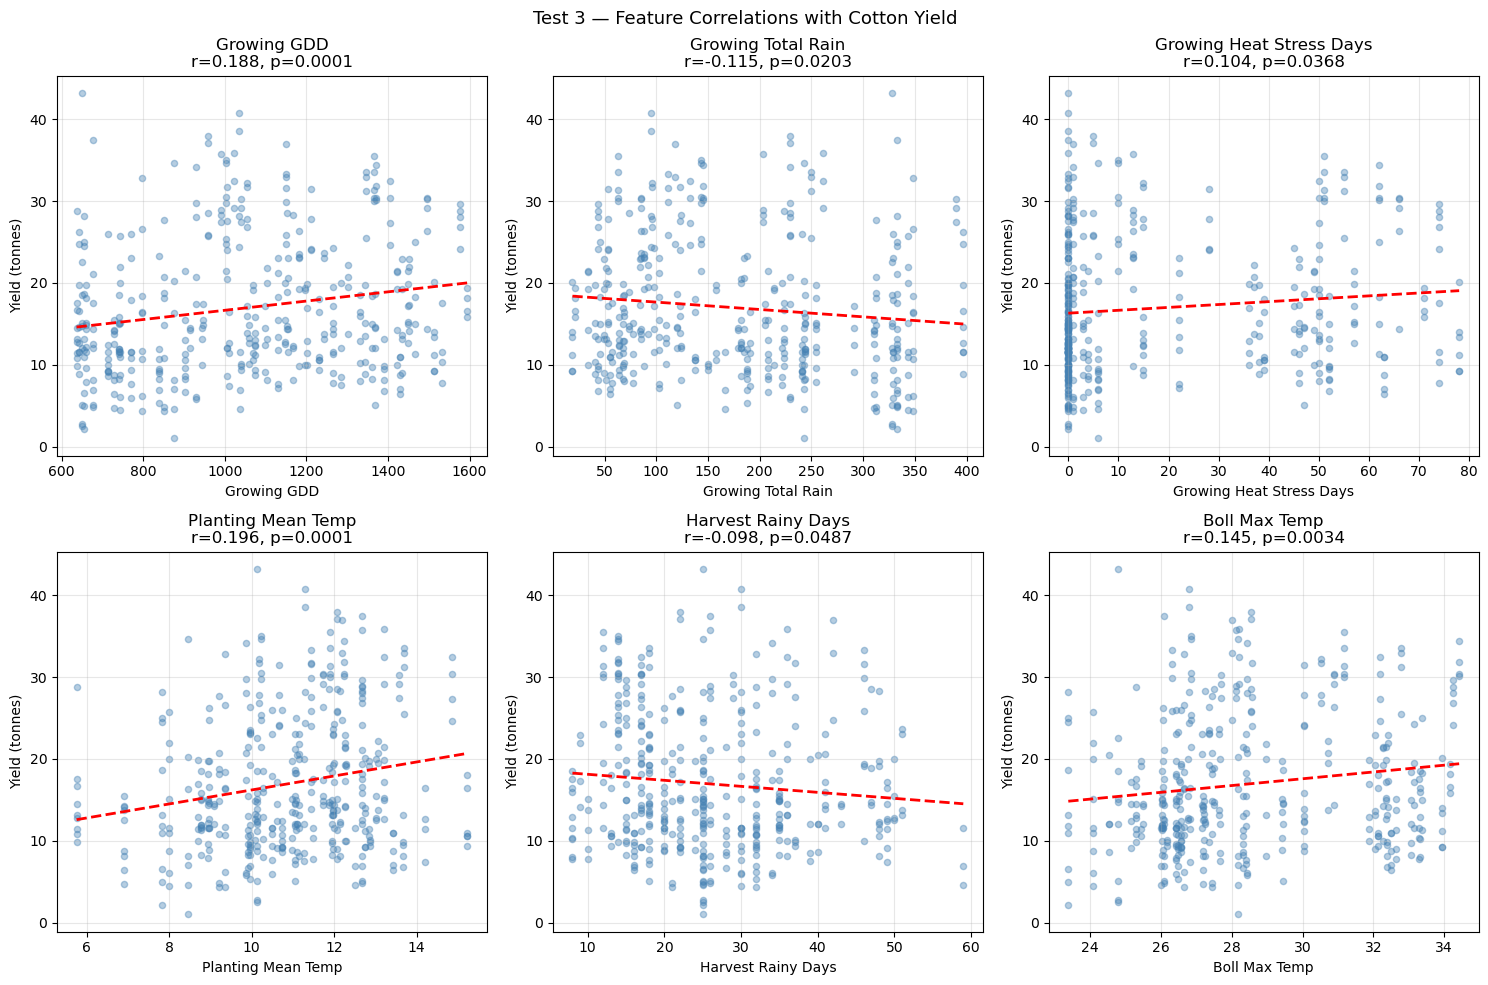

Saved: stat_03_correlations.png


In [4]:
print("=" * 55)
print("TEST 3 — Feature Correlations with Yield")
print("Pearson + Spearman Correlation Tests")
print("H0: feature has NO correlation with yield (r=0)")
print("H1: feature IS correlated with yield")
print("=" * 55)

features_to_test = [
    ("growing_GDD",              "Growing GDD"),
    ("growing_total_rain",       "Growing Total Rain"),
    ("growing_heat_stress_days", "Growing Heat Stress Days"),
    ("planting_temp_mean",       "Planting Mean Temp"),
    ("harvest_rainy_days",       "Harvest Rainy Days"),
    ("boll_forming_temp_max_mean","Boll Max Temp"),
]

results = []
for col, label in features_to_test:
    subset = df[[col, "yield_tonnes"]].dropna()
    pr, pp = pearsonr(subset[col],  subset["yield_tonnes"])
    sr, sp = spearmanr(subset[col], subset["yield_tonnes"])
    results.append({
        "Feature":   label,
        "Pearson r": round(pr, 3),
        "Pearson p": round(pp, 4),
        "Spearman r":round(sr, 3),
        "Spearman p":round(sp, 4),
        "Significant": "✓" if pp < 0.05 else "✗"
    })

results_df = pd.DataFrame(results)
print(f"\n{results_df.to_string(index=False)}")

# Plot top correlations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (col, label) in zip(axes.flat, features_to_test):
    ax.scatter(df[col], df["yield_tonnes"], alpha=0.4, s=20, color="steelblue")
    m, b = np.polyfit(df[col].fillna(df[col].mean()),
                      df["yield_tonnes"], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m * x_line + b, "r--", linewidth=2)
    pr, pp = pearsonr(df[col].fillna(df[col].mean()), df["yield_tonnes"])
    ax.set_title(f"{label}\nr={pr:.3f}, p={pp:.4f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Yield (tonnes)")
    ax.grid(True, alpha=0.3)

plt.suptitle("Test 3 — Feature Correlations with Cotton Yield", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "stat_03_correlations.png"), dpi=150)
plt.show()
print("Saved: stat_03_correlations.png")

## Zone Yield Differences (ANOVA):

TEST 4 — Yield Differences Between Weather Zones
One-Way ANOVA
H0: all zones have the SAME mean yield
H1: at least one zone has a different mean yield

  Zone summary:
                  mean   std  count
weather_station                    
Ganja            16.00  8.65    197
Lankaran         18.07  8.42     89
Sabirabad        17.65  7.78    121

  F-statistic: 2.4920
  p-value:     0.0840
  Result: FAIL TO REJECT H0 → no significant zone difference


C:\Users\User\AppData\Local\Temp\ipykernel_19956\1351958350.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=zones, patch_artist=True)


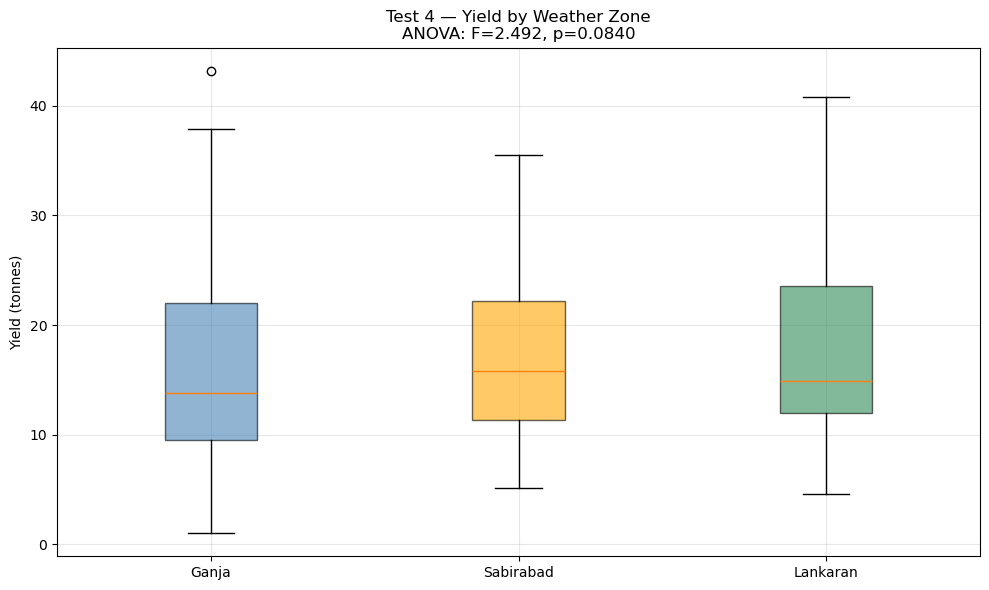

Saved: stat_04_zone_anova.png


In [6]:
print("=" * 55)
print("TEST 4 — Yield Differences Between Weather Zones")
print("One-Way ANOVA")
print("H0: all zones have the SAME mean yield")
print("H1: at least one zone has a different mean yield")
print("=" * 55)

groups = [
    group["yield_tonnes"].values
    for _, group in df.groupby("weather_station")
]
zone_means = df.groupby("weather_station")["yield_tonnes"].agg(
    ["mean","std","count"]
).round(2)
print(f"\n  Zone summary:")
print(zone_means.to_string())

f_stat, p_val = f_oneway(*groups)
print(f"\n  F-statistic: {f_stat:.4f}")
print(f"  p-value:     {p_val:.4f}")

if p_val < 0.05:
    print("  Result: REJECT H0 ✓ → zones have significantly different yields")
else:
    print("  Result: FAIL TO REJECT H0 → no significant zone difference")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
zones  = df["weather_station"].unique()
data   = [df[df["weather_station"] == z]["yield_tonnes"] for z in zones]
bp = ax.boxplot(data, labels=zones, patch_artist=True)
colors = ["steelblue","orange","seagreen","purple","brown"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title(f"Test 4 — Yield by Weather Zone\n"
             f"ANOVA: F={f_stat:.3f}, p={p_val:.4f}")
ax.set_ylabel("Yield (tonnes)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "stat_04_zone_anova.png"), dpi=150)
plt.show()
print("Saved: stat_04_zone_anova.png")

## Multicollinearity Check (VIF):

TEST 5 — Multicollinearity Check (VIF Scores)
VIF > 10 = severe multicollinearity problem
VIF 5-10 = moderate, VIF < 5 = acceptable

                   Feature    VIF Status
     harvest_humidity_mean 452.79 ✗ HIGH
boll_forming_temp_max_mean 371.41 ✗ HIGH
               growing_GDD 188.99 ✗ HIGH
        planting_temp_mean  67.03 ✗ HIGH
        harvest_rainy_days  32.92 ✗ HIGH
        growing_total_rain  17.62 ✗ HIGH
  growing_heat_stress_days  13.45 ✗ HIGH
    growing_max_dry_streak  11.66 ✗ HIGH


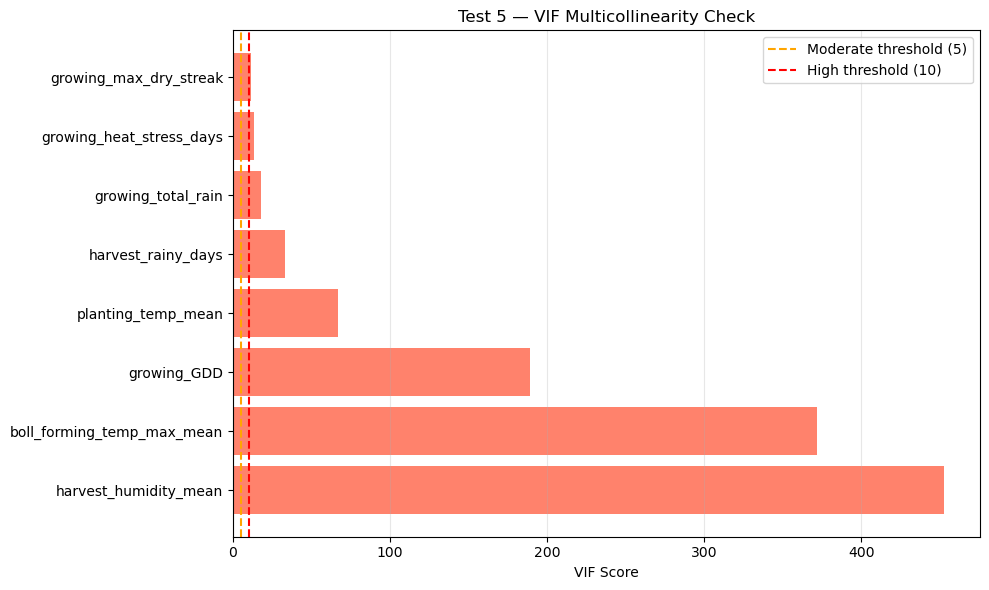

Saved: stat_05_vif.png


In [7]:
print("=" * 55)
print("TEST 5 — Multicollinearity Check (VIF Scores)")
print("VIF > 10 = severe multicollinearity problem")
print("VIF 5-10 = moderate, VIF < 5 = acceptable")
print("=" * 55)

from statsmodels.stats.outliers_influence import variance_inflation_factor

key_features = [
    "growing_GDD",
    "growing_total_rain",
    "growing_heat_stress_days",
    "planting_temp_mean",
    "harvest_rainy_days",
    "boll_forming_temp_max_mean",
    "growing_max_dry_streak",
    "harvest_humidity_mean"
]

vif_data = df[key_features].dropna()
vif_scores = pd.DataFrame({
    "Feature": key_features,
    "VIF": [
        variance_inflation_factor(vif_data.values, i)
        for i in range(len(key_features))
    ]
}).sort_values("VIF", ascending=False)
vif_scores["VIF"] = vif_scores["VIF"].round(2)
vif_scores["Status"] = vif_scores["VIF"].apply(
    lambda v: "✗ HIGH" if v > 10 else ("⚠ MODERATE" if v > 5 else "✓ OK")
)

print(f"\n{vif_scores.to_string(index=False)}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors_vif = ["tomato" if v > 10 else "orange" if v > 5 else "seagreen"
              for v in vif_scores["VIF"]]
ax.barh(vif_scores["Feature"], vif_scores["VIF"], color=colors_vif, alpha=0.8)
ax.axvline(5,  color="orange", linestyle="--", label="Moderate threshold (5)")
ax.axvline(10, color="red",    linestyle="--", label="High threshold (10)")
ax.set_title("Test 5 — VIF Multicollinearity Check")
ax.set_xlabel("VIF Score")
ax.legend()
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "stat_05_vif.png"), dpi=150)
plt.show()
print("Saved: stat_05_vif.png")

## Confidence Intervals on Yield by Zone:

TEST 6 — 95% Confidence Intervals on Mean Yield
By weather zone

     Zone   n  Mean  CI Lower  CI Upper  Margin
    Ganja 197 16.00     14.79     17.22    1.22
 Lankaran  89 18.07     16.29     19.84    1.77
Sabirabad 121 17.65     16.25     19.05    1.40


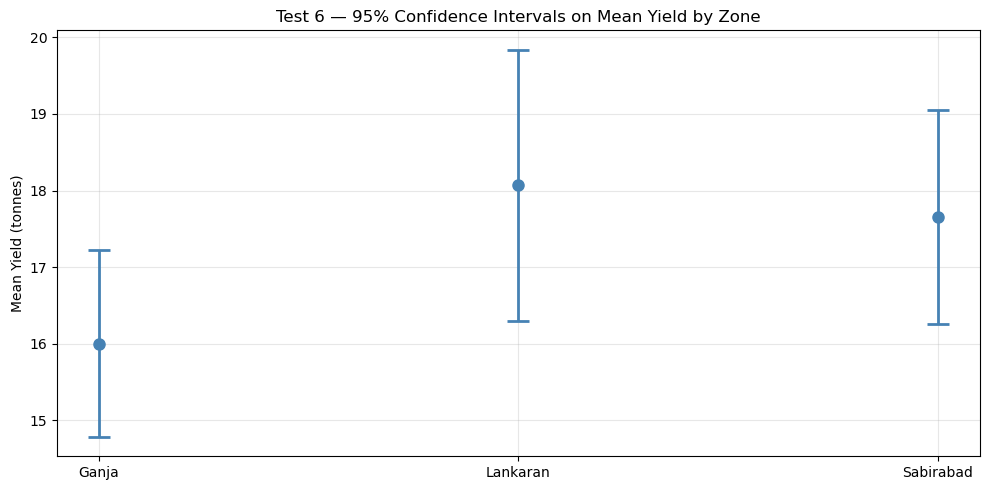

Saved: stat_06_confidence_intervals.png


In [8]:
print("=" * 55)
print("TEST 6 — 95% Confidence Intervals on Mean Yield")
print("By weather zone")
print("=" * 55)

ci_results = []
for zone, group in df.groupby("weather_station"):
    n    = len(group)
    mean = group["yield_tonnes"].mean()
    se   = stats.sem(group["yield_tonnes"])
    ci   = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
    ci_results.append({
        "Zone":    zone,
        "n":       n,
        "Mean":    round(mean, 2),
        "CI Lower":round(ci[0], 2),
        "CI Upper":round(ci[1], 2),
        "Margin":  round(ci[1] - mean, 2)
    })

ci_df = pd.DataFrame(ci_results)
print(f"\n{ci_df.to_string(index=False)}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    ci_df["Zone"], ci_df["Mean"],
    yerr=ci_df["Margin"],
    fmt="o", capsize=8, capthick=2,
    markersize=8, color="steelblue", linewidth=2
)
ax.set_title("Test 6 — 95% Confidence Intervals on Mean Yield by Zone")
ax.set_ylabel("Mean Yield (tonnes)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "stat_06_confidence_intervals.png"), dpi=150)
plt.show()
print("Saved: stat_06_confidence_intervals.png")

## Summary of All Tests:

In [9]:
print("\n" + "=" * 65)
print("STATISTICAL ANALYSIS SUMMARY")
print("=" * 65)

print("""
Test 1 — Normality (Shapiro-Wilk)
  Checks if yield is normally distributed
  Important for choosing correct subsequent tests

Test 2 — Safe vs Risky Years (t-test + Cohen's d)
  Validates that our risk labels correctly identify
  low-yield years with statistical significance
  Effect size tells us HOW LARGE the difference is

Test 3 — Feature Correlations (Pearson + Spearman)
  Identifies which weather features are statistically
  significantly related to cotton yield
  Both linear (Pearson) and rank (Spearman) tested

Test 4 — Zone Differences (One-Way ANOVA)
  Tests whether different climate zones produce
  significantly different yields
  Justifies our zone-based modeling approach

Test 5 — Multicollinearity (VIF)
  Checks if weather features are too correlated
  with each other, which would hurt model reliability
  Guides feature selection for modeling

Test 6 — Confidence Intervals
  95% CI on mean yield per zone
  Shows uncertainty in our estimates
  Will also be applied to model predictions
""")

print("All statistical charts saved to reports/figures/")
print("stat_01_normality.png")
print("stat_02_safe_vs_risky.png")
print("stat_03_correlations.png")
print("stat_04_zone_anova.png")
print("stat_05_vif.png")
print("stat_06_confidence_intervals.png")

con.close()


STATISTICAL ANALYSIS SUMMARY

Test 1 — Normality (Shapiro-Wilk)
  Checks if yield is normally distributed
  Important for choosing correct subsequent tests

Test 2 — Safe vs Risky Years (t-test + Cohen's d)
  Validates that our risk labels correctly identify
  low-yield years with statistical significance
  Effect size tells us HOW LARGE the difference is

Test 3 — Feature Correlations (Pearson + Spearman)
  Identifies which weather features are statistically
  significantly related to cotton yield
  Both linear (Pearson) and rank (Spearman) tested

Test 4 — Zone Differences (One-Way ANOVA)
  Tests whether different climate zones produce
  significantly different yields
  Justifies our zone-based modeling approach

Test 5 — Multicollinearity (VIF)
  Checks if weather features are too correlated
  with each other, which would hurt model reliability
  Guides feature selection for modeling

Test 6 — Confidence Intervals
  95% CI on mean yield per zone
  Shows uncertainty in our estimates